# Evaluación de supuestos de los modelos SARFIMA

Este notebook evalúa los modelos SARFIMA guardados en `modelos`. La implementación del proyecto aplica diferenciación fraccional y después ajusta un SARIMA con `pmdarima`; por ello, los residuos analizados son las innovaciones del modelo interno sobre la serie transformada, no errores expresados en la escala original.

Se revisan media cero, ausencia de autocorrelación, normalidad, homocedasticidad, estacionariedad después de la diferenciación fraccional, convergencia y raíces AR/MA. La normalidad no es indispensable para obtener predicciones puntuales, pero sí afecta la inferencia y los intervalos gaussianos.

In [1]:
import __main__
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy.stats import jarque_bera, ttest_1samp
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.tsa.stattools import adfuller, kpss

from modelo_SARFIMA import (
    ModeloSARFIMA,
    diferenciacion_fraccional,
    pesos_diferenciacion_fraccional,
)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda valor: f"{valor:.4f}")

## Carga e inventario

Algunos archivos fueron serializados cuando la clase estaba definida en `__main__` y otros desde `modelo_SARFIMA`. Las asignaciones siguientes permiten cargar ambos formatos sin modificar los modelos.

In [2]:
__main__.ModeloSARFIMA = ModeloSARFIMA
__main__.diferenciacion_fraccional = diferenciacion_fraccional
__main__.pesos_diferenciacion_fraccional = pesos_diferenciacion_fraccional

CARPETA_MODELOS = Path("modelos")
rutas_sarfima = sorted(CARPETA_MODELOS.glob("SARFIMA_*.joblib"))

if not rutas_sarfima:
    raise FileNotFoundError(f"No se encontraron modelos SARFIMA en {CARPETA_MODELOS.resolve()}")

with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="You've deserialized an ARIMA.*")
    modelos_sarfima = {ruta.stem.removeprefix("SARFIMA_"): joblib.load(ruta) for ruta in rutas_sarfima}

print(f"Modelos SARFIMA encontrados: {len(modelos_sarfima)}")
print("\n".join(modelos_sarfima))

Modelos SARFIMA encontrados: 22
FX_AUDJPY
FX_EURCHF
FX_EURNZD
FX_EURUSD
FX_GBPUSD
FX_NOKEUR
FX_NOKJPY
FX_NZDUSD
FX_ZARUSD
US_Stock_BKR_adj_close
US_Stock_CCJ_adj_close
US_Stock_COP_adj_close
US_Stock_EFA_adj_close
US_Stock_EWJ_adj_close
US_Stock_NUE_adj_close
US_Stock_SCCO_adj_close
US_Stock_SPYV_adj_close
US_Stock_URA_adj_close
US_Stock_VTV_adj_close
US_Stock_VXUS_adj_close
US_Stock_XLB_adj_close
US_Stock_XLE_adj_close


In [3]:
def inventario_modelo(nombre, modelo):
    arima = modelo.modelo
    convergencia = arima.arima_res_.mle_retvals.get("converged", np.nan)
    return {
        "serie": nombre,
        "d_fraccional": modelo.d_fraccional,
        "periodo": modelo.periodo_estacional,
        "orden": str(arima.order),
        "orden_estacional": str(arima.seasonal_order),
        "n_entrenamiento": len(modelo.historia),
        "AICc": arima.aicc(),
        "convergio": convergencia,
    }

inventario = pd.DataFrame(
    inventario_modelo(nombre, modelo) for nombre, modelo in modelos_sarfima.items()
).set_index("serie")
inventario

,d_fraccional,periodo,orden,orden_estacional,n_entrenamiento,AICc,convergio
serie,,,,,,,
FX_AUDJPY,0.0500,7,"(2, 0, 1)","(0, 0, 0, 7)",1764,-11702.4477,False
FX_EURCHF,0.0500,7,"(3, 0, 2)","(0, 0, 0, 7)",1764,-14868.3476,False
FX_EURNZD,0.1500,7,"(1, 0, 1)","(0, 0, 0, 7)",1764,-12786.3711,True
FX_EURUSD,0.0500,7,"(1, 0, 1)","(0, 0, 0, 7)",1764,-13884.8136,True
FX_GBPUSD,0.0500,7,"(1, 0, 0)","(0, 0, 0, 7)",1764,-13228.5064,False
FX_NOKEUR,0.0500,7,"(1, 0, 3)","(0, 0, 2, 7)",1764,-12403.2257,True
FX_NOKJPY,0.0500,7,"(1, 0, 0)","(0, 0, 1, 7)",1764,-11482.1586,False
FX_NZDUSD,0.1500,7,"(3, 0, 0)","(0, 0, 0, 7)",1764,-12429.5819,False
FX_ZARUSD,0.0500,7,"(1, 0, 0)","(2, 0, 2, 7)",1764,-10885.0707,True


## Pruebas de diagnóstico

Se descarta un periodo de inicialización (`burn-in`) igual al máximo entre 10 observaciones, dos ciclos estacionales y el alcance de los términos AR/MA. Esto evita que el primer residuo, generado por las condiciones iniciales del ARIMA, domine las pruebas.

Criterios con $\alpha=0.05$:

- Media cero: no rechazar la prueba t.
- Ruido blanco: no rechazar Ljung-Box en 1, 2 y 3 periodos estacionales. Los grados de libertad descuentan los términos AR y MA.
- Normalidad: no rechazar Jarque-Bera.
- Homocedasticidad: no rechazar ARCH-LM.
- Serie transformada estacionaria: rechazar raíz unitaria con ADF y no rechazar estacionariedad con KPSS.
- Estabilidad: raíces AR y MA fuera del círculo unitario.

In [4]:
ALFA = 0.05
series_diagnostico = {}

def minimo_modulo_raices(funcion_raices):
    raices = np.asarray(funcion_raices(), dtype=complex)
    return float(np.min(np.abs(raices))) if raices.size else np.inf


def evaluar_supuestos_sarfima(nombre, modelo):
    arima = modelo.modelo
    p, _, q = arima.order
    P, _, Q, m = arima.seasonal_order
    m = m or modelo.periodo_estacional or 1
    model_df = p + q + P + Q
    burn_in = max(10, 2 * m, p + q + P * m + Q * m)

    residuos = np.asarray(arima.resid(), dtype=float)
    residuos = residuos[burn_in:]
    residuos = residuos[np.isfinite(residuos)]

    serie_diff = diferenciacion_fraccional(modelo.historia, modelo.d_fraccional)[burn_in:]
    serie_diff = serie_diff[np.isfinite(serie_diff)]

    lags = [lag for lag in (m, 2 * m, 3 * m) if lag > model_df and lag < len(residuos)]
    if not lags:
        lags = [min(max(model_df + 1, 1), len(residuos) - 1)]
    ljung_box = acorr_ljungbox(residuos, lags=lags, model_df=model_df, return_df=True)

    prueba_media = ttest_1samp(residuos, popmean=0.0)
    prueba_jb = jarque_bera(residuos)
    arch_lags = min(3 * m, int(np.sqrt(len(residuos))))
    prueba_arch = het_arch(residuos, nlags=arch_lags)
    prueba_adf = adfuller(serie_diff, autolag="AIC")
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        prueba_kpss = kpss(serie_diff, regression="c", nlags="auto")

    raiz_ar_min = minimo_modulo_raices(arima.arroots)
    raiz_ma_min = minimo_modulo_raices(arima.maroots)
    series_diagnostico[nombre] = {"residuos": residuos, "serie_diff": serie_diff}

    resultado = {
        "serie": nombre,
        "n_residuos": len(residuos),
        "burn_in": burn_in,
        "media": residuos.mean(),
        "media_p": prueba_media.pvalue,
        "LB_p_min": ljung_box["lb_pvalue"].min(),
        "JB_p": prueba_jb.pvalue,
        "ARCH_p": prueba_arch[1],
        "ADF_p": prueba_adf[1],
        "KPSS_p": prueba_kpss[1],
        "raiz_AR_min": raiz_ar_min,
        "raiz_MA_min": raiz_ma_min,
    }
    for lag, p_valor in ljung_box["lb_pvalue"].items():
        resultado[f"LB_{lag}_p"] = p_valor
    return resultado


resultados = pd.DataFrame(
    evaluar_supuestos_sarfima(nombre, modelo)
    for nombre, modelo in modelos_sarfima.items()
).set_index("serie")

resultados["media_cero"] = resultados["media_p"] > ALFA
resultados["ruido_blanco"] = resultados["LB_p_min"] > ALFA
resultados["normalidad"] = resultados["JB_p"] > ALFA
resultados["homocedasticidad"] = resultados["ARCH_p"] > ALFA
resultados["estacionaria_diff"] = (resultados["ADF_p"] < ALFA) & (resultados["KPSS_p"] > ALFA)
resultados["raices_estables"] = (resultados["raiz_AR_min"] > 1) & (resultados["raiz_MA_min"] > 1)
resultados

,n_residuos,burn_in,media,media_p,LB_p_min,JB_p,ARCH_p,ADF_p,KPSS_p,raiz_AR_min,raiz_MA_min,LB_7_p,LB_14_p,LB_21_p,media_cero,ruido_blanco,normalidad,homocedasticidad,estacionaria_diff,raices_estables
serie,,,,,,,,,,,,,,,,,,,,
FX_AUDJPY,1750,14,0.0001,0.7755,0.0000,0.0000,0.0000,0.0000,0.0100,1.0001,1.3461,0.0000,0.0000,0.0000,True,False,False,False,False,True
FX_EURCHF,1750,14,-0.0001,0.4821,0.0000,0.0000,0.0000,0.7031,0.0100,1.0016,1.1544,0.0000,0.0000,0.0000,True,False,False,False,False,True
FX_EURNZD,1750,14,-0.0002,0.2331,0.0000,0.0000,0.0000,0.0010,0.0100,1.0005,4.0434,0.0000,0.0000,0.0000,True,False,False,False,False,True
FX_EURUSD,1750,14,-0.0001,0.2884,0.0000,0.0000,0.0000,0.0922,0.0100,1.0070,12.2688,0.0000,0.0001,0.0008,True,False,False,False,False,True
FX_GBPUSD,1750,14,-0.0001,0.3386,0.0808,0.0000,0.0000,0.0208,0.0100,1.0111,inf,0.0808,0.1036,0.2983,True,True,False,False,False,True
FX_NOKEUR,1746,18,-0.0001,0.7252,0.0000,0.0000,0.0000,0.0005,0.0100,1.0001,1.2448,0.0000,0.0000,0.0000,True,False,False,False,False,True
FX_NOKJPY,1750,14,-0.0005,0.0212,0.0000,0.0000,0.0000,0.0002,0.0100,1.0016,1.3924,0.0000,0.0000,0.0003,False,False,False,False,False,True
FX_NZDUSD,1750,14,0.0001,0.3925,0.0061,0.0000,0.0000,0.0109,0.0108,1.0129,inf,0.0061,0.0374,0.0266,True,False,False,False,False,True
FX_ZARUSD,1735,29,0.0003,0.1718,0.0000,0.0000,0.0000,0.0316,0.0213,1.0000,1.0169,0.0000,0.0000,0.0000,True,False,False,False,False,True


## Resumen breve

La siguiente celda cuenta cuántos modelos cumplen cada condición y señala los casos que requieren revisión. Un rechazo de normalidad aislado suele ser menos grave para pronóstico puntual que la autocorrelación o el efecto ARCH remanentes.

In [5]:
criterios = [
    "media_cero",
    "ruido_blanco",
    "normalidad",
    "homocedasticidad",
    "estacionaria_diff",
    "raices_estables",
]
resumen = pd.DataFrame({
    "cumplen": resultados[criterios].sum(),
    "no_cumplen": (~resultados[criterios]).sum(),
    "porcentaje_cumplimiento": 100 * resultados[criterios].mean(),
})
display(resumen)

for criterio in criterios:
    fallan = resultados.index[~resultados[criterio]].tolist()
    detalle = ", ".join(fallan) if fallan else "ninguno"
    print(f"{criterio}: {detalle}")

,cumplen,no_cumplen,porcentaje_cumplimiento
media_cero,18,4,81.8182
ruido_blanco,3,19,13.6364
normalidad,0,22,0.0000
homocedasticidad,0,22,0.0000
estacionaria_diff,0,22,0.0000
raices_estables,22,0,100.0000


media_cero: FX_NOKJPY, US_Stock_EWJ_adj_close, US_Stock_SPYV_adj_close, US_Stock_VXUS_adj_close
ruido_blanco: FX_AUDJPY, FX_EURCHF, FX_EURNZD, FX_EURUSD, FX_NOKEUR, FX_NOKJPY, FX_NZDUSD, FX_ZARUSD, US_Stock_BKR_adj_close, US_Stock_COP_adj_close, US_Stock_EFA_adj_close, US_Stock_EWJ_adj_close, US_Stock_NUE_adj_close, US_Stock_SCCO_adj_close, US_Stock_SPYV_adj_close, US_Stock_VTV_adj_close, US_Stock_VXUS_adj_close, US_Stock_XLB_adj_close, US_Stock_XLE_adj_close
normalidad: FX_AUDJPY, FX_EURCHF, FX_EURNZD, FX_EURUSD, FX_GBPUSD, FX_NOKEUR, FX_NOKJPY, FX_NZDUSD, FX_ZARUSD, US_Stock_BKR_adj_close, US_Stock_CCJ_adj_close, US_Stock_COP_adj_close, US_Stock_EFA_adj_close, US_Stock_EWJ_adj_close, US_Stock_NUE_adj_close, US_Stock_SCCO_adj_close, US_Stock_SPYV_adj_close, US_Stock_URA_adj_close, US_Stock_VTV_adj_close, US_Stock_VXUS_adj_close, US_Stock_XLB_adj_close, US_Stock_XLE_adj_close
homocedasticidad: FX_AUDJPY, FX_EURCHF, FX_EURNZD, FX_EURUSD, FX_GBPUSD, FX_NOKEUR, FX_NOKJPY, FX_NZDUSD, FX_ZA

In [6]:
n_modelos = len(resultados)
print("Lectura breve de los resultados:")
print(f"- {resultados['ruido_blanco'].sum()} de {n_modelos} modelos no presentan autocorrelación residual significativa.")
print(f"- {resultados['homocedasticidad'].sum()} de {n_modelos} no muestran efecto ARCH remanente.")
print(f"- {resultados['normalidad'].sum()} de {n_modelos} son compatibles con normalidad.")
print(f"- {resultados['estacionaria_diff'].sum()} de {n_modelos} pasan conjuntamente ADF y KPSS tras diferenciar.")
print(f"- {resultados['raices_estables'].sum()} de {n_modelos} tienen raíces AR y MA fuera del círculo unitario.")
print("- Si falla ruido blanco, conviene revisar los órdenes AR/MA; si falla ARCH, considerar SARFIMA-GARCH.")

Lectura breve de los resultados:
- 3 de 22 modelos no presentan autocorrelación residual significativa.
- 0 de 22 no muestran efecto ARCH remanente.
- 0 de 22 son compatibles con normalidad.
- 0 de 22 pasan conjuntamente ADF y KPSS tras diferenciar.
- 22 de 22 tienen raíces AR y MA fuera del círculo unitario.
- Si falla ruido blanco, conviene revisar los órdenes AR/MA; si falla ARCH, considerar SARFIMA-GARCH.


## Diagnóstico gráfico

Para conservar un análisis breve se grafica por defecto el modelo con el menor p-valor de Ljung-Box. Se puede asignar cualquier clave de `modelos_sarfima` a `NOMBRE_MODELO`.

Modelo mostrado: US_Stock_VTV_adj_close


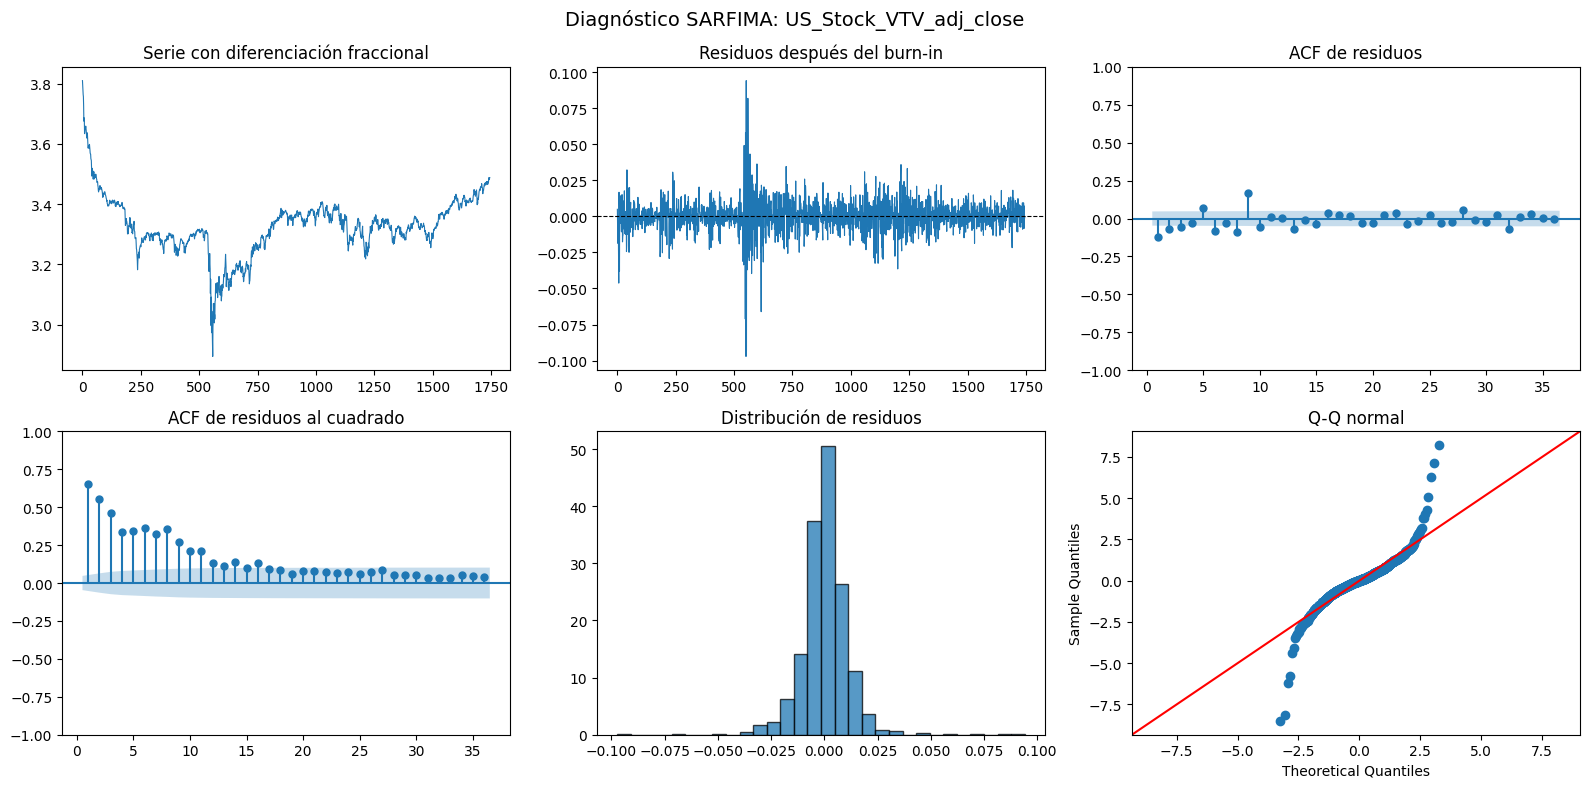

In [7]:
def diagnosticos_graficos(nombre):
    residuos = series_diagnostico[nombre]["residuos"]
    serie_diff = series_diagnostico[nombre]["serie_diff"]
    max_lags = min(36, len(residuos) // 2 - 1)

    fig, ejes = plt.subplots(2, 3, figsize=(16, 8))
    ejes[0, 0].plot(serie_diff, linewidth=0.8)
    ejes[0, 0].set_title("Serie con diferenciación fraccional")
    ejes[0, 1].plot(residuos, linewidth=0.8)
    ejes[0, 1].axhline(0, color="black", linestyle="--", linewidth=0.8)
    ejes[0, 1].set_title("Residuos después del burn-in")
    plot_acf(residuos, lags=max_lags, ax=ejes[0, 2], zero=False)
    ejes[0, 2].set_title("ACF de residuos")
    plot_acf(residuos ** 2, lags=max_lags, ax=ejes[1, 0], zero=False)
    ejes[1, 0].set_title("ACF de residuos al cuadrado")
    ejes[1, 1].hist(residuos, bins=30, density=True, alpha=0.75, edgecolor="black")
    ejes[1, 1].set_title("Distribución de residuos")
    sm.qqplot(residuos, line="45", fit=True, ax=ejes[1, 2])
    ejes[1, 2].set_title("Q-Q normal")
    fig.suptitle(f"Diagnóstico SARFIMA: {nombre}", fontsize=14)
    fig.tight_layout()
    plt.show()

NOMBRE_MODELO = resultados["LB_p_min"].idxmin()
print(f"Modelo mostrado: {NOMBRE_MODELO}")
diagnosticos_graficos(NOMBRE_MODELO)

## Consideraciones finales

- Ljung-Box evalúa si la dinámica de la media quedó suficientemente capturada. Un p-valor bajo sugiere revisar los órdenes del SARFIMA.
- ARCH-LM evalúa dependencia en la varianza. Un p-valor bajo sugiere complementar la media SARFIMA con una especificación GARCH.
- Jarque-Bera suele rechazar normalidad en datos financieros por asimetría y colas pesadas; esto afecta principalmente intervalos e inferencia.
- ADF y KPSS verifican estacionariedad, no demuestran por sí solas que toda la memoria larga haya desaparecido.
- Esta implementación estima primero el parámetro fraccional y luego el SARIMA. No es una estimación SARFIMA conjunta y no incorpora la incertidumbre de $d$ en los intervalos.
- Los modelos fueron creados con `pmdarima 2.0.4`; conviene reproducir el entorno original antes de reajustarlos o usarlos en producción.